# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [5]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.posterior_optimization import MAPEstimator

In [6]:
# Huang 2018 
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
HD143006 = {'inc': 18.6, 'pa': 169, 'dra':-5.9e-3, 'ddec':21.7e-3, 'rout': 0.518*3, 'disk_name': 'HD143006'}

In [7]:
best_Elias27 = {'m': -3.297430763696686, 'c': 316115113583956.4, 'l': 44039.6957302716}
best_AS209 = {'m': -1.3620915465005585, 'c': 4681.0681578390195, 'l': 72454.15132114716}

In [8]:
data =  Elias27

In [9]:

dir = "./../../data/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"

inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
rout = data['rout']

# Frank Parameters
N = 500

# Load data
file = np.load(data_file)
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

geom = Geometry(inc, pa, dra, ddec)
frank2d = Frank2D(N, rout, geom)

### Creating simulated disc

In [10]:
import numpy as np
from scipy.special import j0, j1

def synthetic_uvtable_symmetric(u, v,
                                sigma_core=0.03,
                                R_rings=[0.25, 0.5,  0.7],
                                width_rings=[0.04, 0.02, 0.04],
                                amp_core=0.04,
                                amp_rings=[0.04, 0.02, 0.01],
                                weights=None):
    """
    Generate synthetic uvtable for a disk with a uniform disk component and Gaussian-width rings.
    Parameters:
    -----------
    u, v : array_like
        UV coordinates (in wavelengths)
    R_disk : float
        Radius of uniform disk (arcsec)
    R_rings : list of float
        Radii of ring centers (arcsec)
    width_rings : list of float
        Widths (sigma) of each ring (arcsec)
    amp_disk : float
        Amplitude of the uniform disk component
    amp_rings : list of float
        Amplitude of each ring
    rad_to_arcsec : float
        Conversion from radians to arcseconds (default = 206265)
    weights : array_like, optional
        Visibility weights (default = 1)
    Returns:
    --------
    uvtable : dict
        {'u': u, 'v': v, 'vis': Vis, 'weights': weights}
    """
    
    baseline = np.sqrt(u**2 + v**2)
    
    # --- Uniform disk ---
    V_core = amp_core * np.exp(-2 * (np.pi * (sigma_core / rad_to_arcsec) * baseline)**2)
    
    # --- Gaussian-width rings ---
    V_rings = np.zeros_like(baseline)
    for A, R, w in zip(amp_rings, R_rings, width_rings):
        arg = 2 * np.pi * (R / rad_to_arcsec) * baseline
        blur = np.exp(-2 * (np.pi * (w / rad_to_arcsec) * baseline)**2)
        V_rings += A * j0(arg) * blur
    
    # --- Combine ---
    V_total = V_core + V_rings
    Vis = V_total + 0j  # purely real (axisymmetric)
    
    if weights is None:
        weights = np.ones_like(u)
    
    uvtable = {
        'u': u,
        'v': v,
        'vis': Vis,
        'weights': weights
    }
    
    return uvtable

In [11]:
frank2d.process_vis(uvtable)

Setting gridded data...


In [12]:
u, v = frank2d.gridded_data['u'], frank2d.gridded_data['v']

In [13]:
synthetic_data = synthetic_uvtable_symmetric(u, v)

In [14]:
u_syn = synthetic_data['u'].reshape(N, N)
v_syn = synthetic_data['v'].reshape(N, N)
vis_syn = synthetic_data['vis'].reshape(N, N)
weights_syn = synthetic_data['weights'].reshape(N, N)

Text(0.5, 1.0, 'Synthetic visibilities')

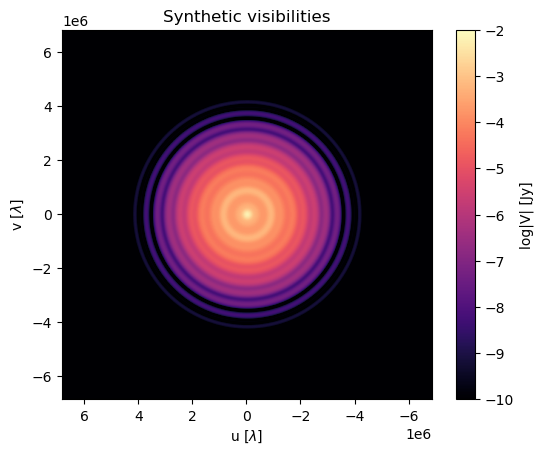

In [38]:
plt.imshow(np.log(np.abs(vis_syn)),
 extent=[u_syn.max(), u_syn.min(), v_syn.min(), v_syn.max()],
 cmap='magma',
 vmin=-10, vmax=-2
)
plt.xlabel(r'u [$\lambda$]')
plt.ylabel(r'v [$\lambda$]')
plt.colorbar(label='log|V| [Jy]')
plt.title('Synthetic visibilities')


In [16]:
params_1 = {'m' : -2, 'c' : 1e8, 'l' : 7e4}
params_2 = {'m' : -1.8, 'c' : 1e9, 'l' : 7e4}
params_3 = {'m' : -3, 'c' : 1e14, 'l' : 7e4}
best_1 = {'m': 3.999453638941259, 'c': 3.136859622218696e-23, 'l': 2.187041830986945e+28} # N = 50

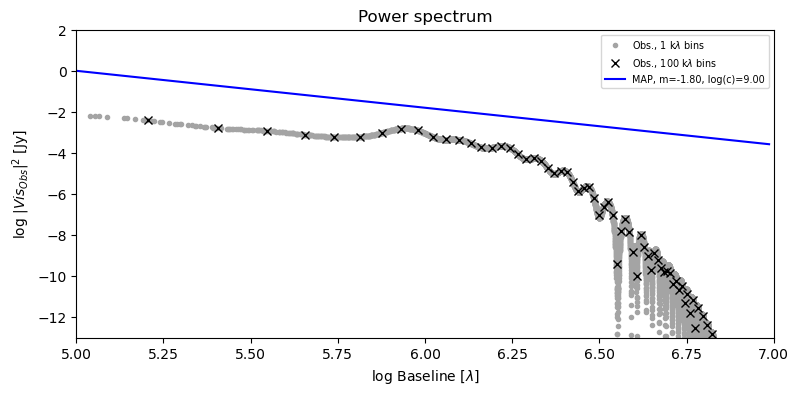

In [39]:
# Plot visibilities gridded.
from frank.utilities import UVDataBinner       
bin_widths=[1e3, 1e5]

u, v = u_syn.flatten(), v_syn.flatten()
Vis = vis_syn.flatten()
Weights = weights_syn.flatten()

baselines = np.hypot(u, v)
binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])
logx = np.log10(binned_vis.uv)
logy = np.log10(np.abs(binned_vis.V)**2)

binned_vis2 = UVDataBinner(baselines, Vis, Weights, bin_widths[1])
logx2 = np.log10(binned_vis2.uv)
logy2 = np.log10(np.abs(binned_vis2.V)**2)

def linear_power_spectrum(logx, m, c):
    return m*logx + np.log10(c)


lgx = np.log10(np.geomspace(np.sort(baselines)[1], baselines.max(), 1000))

lgy1 = linear_power_spectrum(lgx, params_1['m'], params_1['c'])
lgy2 = linear_power_spectrum(lgx, params_2['m'], params_2['c'])
lgy3 = linear_power_spectrum(lgx, params_3['m'], params_3['c'])
#lgy_best = linear_power_spectrum(lgx, best['m'], best['c'])

cs, ms = ['#a4a4a4', 'k'], ['.', 'x']

plt.figure(figsize=(9, 4))
plt.plot(logx, logy, c=cs[0], marker=ms[0], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
plt.plot(logx2, logy2, c=cs[1], marker=ms[1], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

#plt.plot(lgx, lgy1, ls='-', color= 'r', label='MAP, m={:.2f}, log(c)={:.2f}'.format(params_1['m'], np.log10(params_1['c'])))
plt.plot(lgx, lgy2, ls='-', color= 'blue', label='MAP, m={:.2f}, log(c)={:.2f}'.format(params_2['m'], np.log10(params_2['c'])))
#plt.plot(lgx, lgy3, ls='-', color= 'green', label='MAP, m={:.2f}, log(c)={:.2f}'.format(params_3['m'], np.log10(params_3['c'])))
#plt.plot(lgx, lgy_best, ls='--', color= 'orange', label='Best fit, m={:.2f}, log(c)={:.2f}'.format(best['m'], np.log10(best['c'])))

plt.xlabel(r'log Baseline [$\lambda$]', size = 10)
plt.ylabel(r'log $|Vis_{Obs}|^{2}$ [Jy]', size = 10)
plt.legend(loc = 'best', fontsize = 'x-small')
plt.title("Power spectrum")
plt.ylim(-13, 2)
plt.xlim(5, 7)
plt.show()

In [18]:
dx = frank2d.dx/rad_to_arcsec
dy = frank2d.dy/rad_to_arcsec
I_syn = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(vis_syn))).real/(dx * dy)

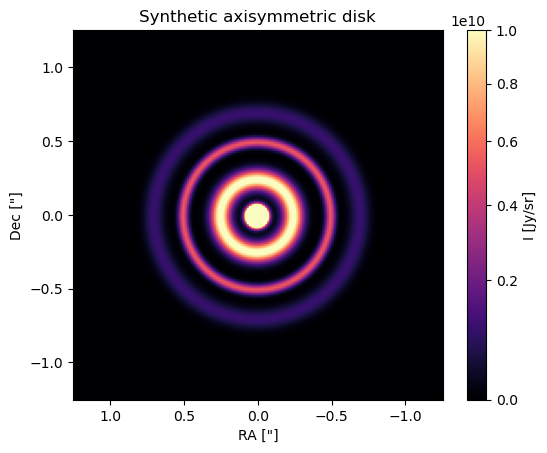

In [41]:
import matplotlib.colors as colors
norm = colors.PowerNorm(gamma = 0.7, vmin = 0, vmax = 1e10)

plt.imshow(I_syn, 
            extent=[-frank2d.Rmax, frank2d.Rmax, -frank2d.Rmax, frank2d.Rmax],
            norm=norm, 
            cmap = 'magma'
            )
plt.xlim(rout/3, -rout/3)
plt.ylim(-rout/3, rout/3)
plt.title('Synthetic axisymmetric disk')
plt.xlabel('RA ["]')
plt.ylabel('Dec ["]')
plt.colorbar(label='I [Jy/sr]')

In [30]:
geom = Geometry(0, 0, 0, 0)

In [31]:
params_2

{'m': -1.8, 'c': 1000000000.0, 'l': 70000.0}

In [32]:
frank2d2 = Frank2D(N, rout, geom)

Setting gridded data...
Setting GP Kernel Wendland...
 + Kernel parameters:  {'m': -1.8, 'c': 1000000000.0, 'l': 70000.0}
Creating sparse linear system...
--> time kernel = 0.57  min |  33.99 seconds
Using preconditioner method:  jacobi
--> time building system = 0.59  min |  35.66 seconds
Solving linear system...
Running solver with maxiter =  50000  and rtol =  1e-08
         * rtol: 1e-08
         * final tolerance: 1.1669307791154439e-07
Final tolerance :  1.1669307791154439e-07
.... iteration:  0
                        -> actual tol:  11.66930779115444 vs  1.1669307791154439e-07
.... iteration:  1
                        -> actual tol:  5.616604119358999 vs  1.1669307791154439e-07
.... iteration:  2
                        -> actual tol:  2.3165434573266013 vs  1.1669307791154439e-07
.... iteration:  3
                        -> actual tol:  0.90767438431983 vs  1.1669307791154439e-07
.... iteration:  4
                        -> actual tol:  0.4098997964612213 vs  1.166930779115

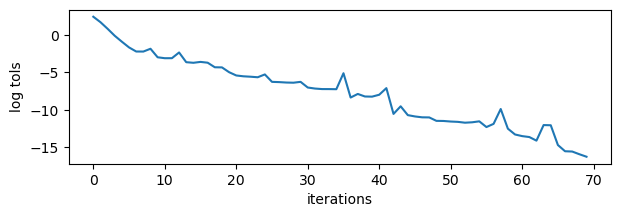

--> time = 1.31  min |  78.42 seconds
               ---> CGM converged?   True
                    x Fit correctly?   True
                     !!!!  Sucess..  !!!!
Building full visibility model...
No unweighted data found. Returning weighted visibility model only.
--> times building full visibility model = 0.57  min |  34.35 seconds


In [33]:
frank2d2.fit(data = synthetic_data, kernel_params = params_2, rtol = 1e-8)

In [34]:
Plot_ = Plot(frank2d2)

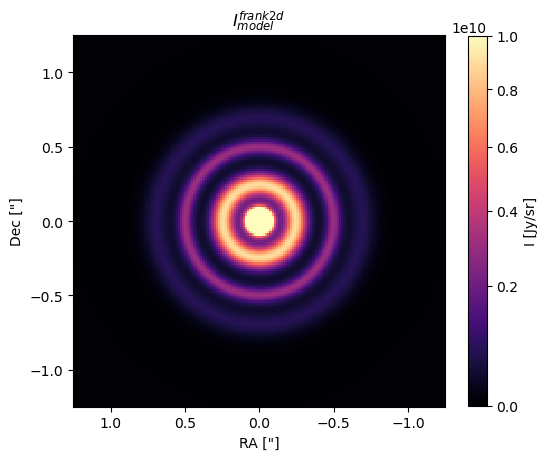

In [42]:
Plot_.intensity(vmax=1e10, gamma = 0.7, zoom = 3, title = r'$I_{model}^{frank2d}$')

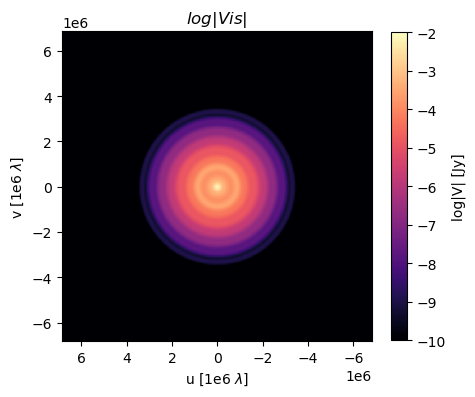

In [36]:
Plot_.visibility(fig_size = 5)

###  Best

In [65]:
initial_guess = {'m': -0.8, 'logl': 4}

In [66]:
frank2d2.search_MAP(initial_guess = initial_guess, N = 80)


Using existing visibility data...
Fitting the visibilities with Frank2D with 2DFT...


  + Time to set up the matrices: 150.95 seconds
Setting the initial guess...
Optimizing the posterior...


In [64]:
frank2d2.MAP

{'m': 3.999453638941259,
 'c': 3.136859622218696e-23,
 'l': 2.187041830986945e+28}